<a href="https://colab.research.google.com/github/walter-04/TFM_Canine/blob/feature%2FVibe_codec/notebooks/unific_size_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from scipy.ndimage import affine_transform
from skimage.segmentation import slic, mark_boundaries
from skimage.exposure import match_histograms
from skimage.segmentation import felzenszwalb
from skimage.transform import SimilarityTransform, warp
from skimage.filters import threshold_otsu
from skimage.morphology import disk, dilation
import skimage
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as pltImage
import math
import scipy
import glob
import cv2

#Libs

In [12]:
from nibabel.affines import rescale_affine, voxel_sizes
from nibabel.processing import resample_from_to
import matplotlib.pyplot as plt
import nibabel as nib
import glob

In [2]:
from google.colab import drive
drive.mount('/content/drive')
path_drive_data = "/content/drive/MyDrive/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Transformar formato

> Esta clase se encarga cambiar las dimensiones de los datos a partir de una imagen de referencia.



In [3]:
# Si no se utiliza drive, especificar ruta
path_base = "/content/drive/MyDrive/"

In [8]:
class Formate_nii:

  def __init__(self, init_nii, file_out):
    '''
    params:
      init_nii: ruta de la imagen a
      file_out: nombre de la carpeta de salida
    '''
    self.cort_z = 250
    self.img_base_nii = nib.load(init_nii)
    self.path_img_base = init_nii.split('/')[-1]
    self.path_out = f"{path_base}/{file_out}/"

  def resample_nii(self, img_nii):
    '''
    params:
      img_nii: imagen a procesar
    return:
      img_nii_resize: imagen procesada
    '''
    new_matrix_affine = rescale_affine(img_nii.affine,
                                shape=img_nii.shape,
                                zooms=voxel_sizes(self.img_base_nii.affine),
                                new_shape=self.img_base_nii.shape)

    img_nii_resize = resample_from_to(img_nii,
                                (self.img_base_nii.shape, new_matrix_affine),
                                order=1, mode='nearest')
    return img_nii_resize

  def run(self, path_data):
    '''
    params:
      path_data: ruta de la carpeta con las imagenes a procesar
    '''
    files_nii = glob.glob(path_data)
    for file in files_nii:
      if self.path_img_base not in file:
        img_nii = nib.load(file)
        name_file_nii = file.split('/')[-1]
        img_nii_resize = self.resample_nii(img_nii)
        print("Tratando:", file)
        print(" * Resample:",img_nii.shape," a ", img_nii_resize.shape)
        nib.save(img_nii_resize, f'{self.path_out}{name_file_nii}')

Ejecución del proceso de redimencionamiento de los ficheros al valor (250, 288, 288)

In [9]:
formate = Formate_nii("/content/drive/MyDrive/data_nii/sub-34_T1w.nii", "data_nii_resize_max")
formate.run("/content/drive/MyDrive/data_nii/*")

Tratando: /content/drive/MyDrive/data_nii/sub-21_T1w.nii
 * Resample: (250, 336, 336)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-23_T1w.nii
 * Resample: (250, 336, 336)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-24_T1w.nii
 * Resample: (250, 336, 336)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-25_T1w.nii
 * Resample: (267, 448, 448)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-26_T1w.nii
 * Resample: (220, 400, 400)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-27_T1w.nii
 * Resample: (220, 336, 336)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-28_T1w.nii
 * Resample: (250, 336, 336)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-22_T1w.nii
 * Resample: (250, 336, 336)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-31_T1w.nii
 * Resample: (250, 336, 336)  a  (400, 560, 560)
Tratando: /content/drive/MyDrive/data_nii/sub-

Se tiene que eliminar comprobaciones

In [7]:
files_nii = glob.glob("/content/drive/MyDrive/data_nii/*")
for file in files_nii:
  img_nii = nib.load(file)
  print(f"{file}:{img_nii.shape}")


/content/drive/MyDrive/data_nii/sub-21_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-23_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-24_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-25_T1w.nii:(267, 448, 448)
/content/drive/MyDrive/data_nii/sub-26_T1w.nii:(220, 400, 400)
/content/drive/MyDrive/data_nii/sub-27_T1w.nii:(220, 336, 336)
/content/drive/MyDrive/data_nii/sub-28_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-22_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-31_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-11_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-12_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-13_T1w.nii:(267, 336, 336)
/content/drive/MyDrive/data_nii/sub-15_T1w.nii:(250, 336, 336)
/content/drive/MyDrive/data_nii/sub-16_T1w.nii:(250, 384, 384)
/content/drive/MyDrive/data_nii/sub-17_T1w.nii:(250, 288, 288)
/content/drive/MyDrive/data_nii/sub-18_T1w.nii:(250, 33

'\n if self.path_img_base not in file:\n  img_nii = nib.load(file)\n  name_file_nii = file.split(\'/\')[-1]\n  img_nii_resize = self.resample_nii(img_nii)\n  print("Tratando:", file)\n  print(" * Resample:",img_nii.shape," a ", img_nii_resize.shape)\n  nib.save(img_nii_resize, f\'{self.path_out}{name_file_nii}\')\n'

In [23]:
image_pe = nib.load("/content/drive/MyDrive/data_nii_resize/sub-01_T1w.nii")
image_pe_2 = nib.load("/content/drive/MyDrive/data_nii/sub-01_T1w.nii")
img_grand = nib.load("/content/drive/MyDrive/data_nii_resize_max/sub-01_T1w.nii")

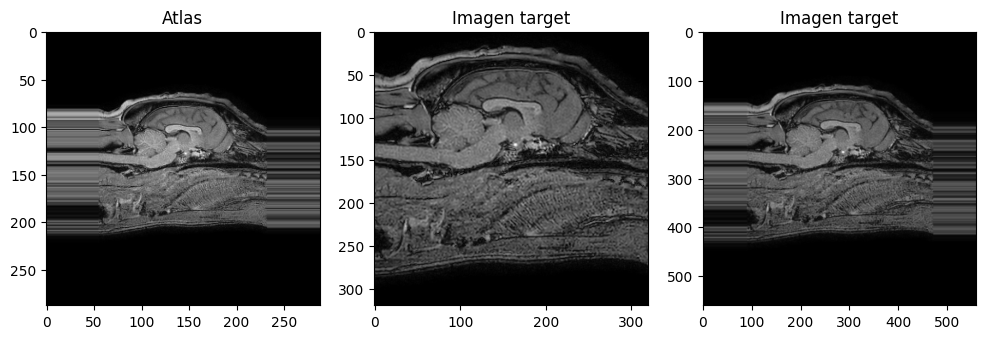

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes.ravel()
ax[0].set_title('Atlas')
ax[0].imshow(image_pe.get_fdata()[125,:,:], cmap='Greys_r')
ax[1].set_title('Imagen target')
ax[1].imshow(image_pe_2.get_fdata()[125,:,:], cmap='Greys_r')
ax[2].set_title('Imagen target')
ax[2].imshow(img_grand.get_fdata()[200,:,:], cmap='Greys_r')

In [ ]:
atlas_resize.shape

(250, 560, 560)

In [ ]:
[[x,list_info.count(x)] for x in set(list_info)]

[[267, 2],
 [300, 2],
 [268, 1],
 [333, 1],
 [400, 1],
 [280, 1],
 [250, 27],
 [220, 2]]

(array([ 8., 14.,  5.,  1.,  3.,  1.,  2.,  2.,  0.,  1.]),
 array([288. , 323.2, 358.4, 393.6, 428.8, 464. , 499.2, 534.4, 569.6,
        604.8, 640. ]),
 <BarContainer object of 10 artists>)

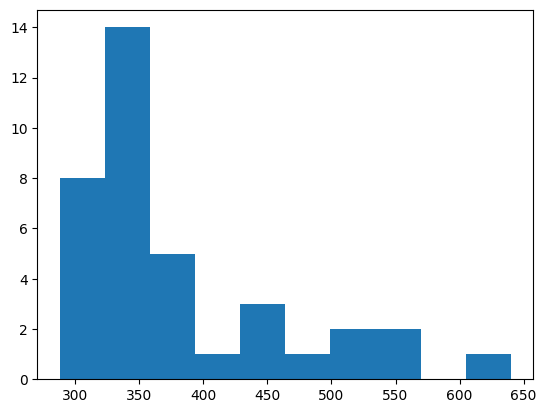

In [ ]:
plt.hist(list_info)